### Import Libraries.

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_cohere import ChatCohere
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
# load the env variables.
load_dotenv()

True

In [3]:
# create the model object.
chat_model = ChatCohere(
    model="command-a-03-2025",
    temperature=0
)

In [4]:
# define the state. 
class blogState(TypedDict): 
    topic: str 
    outline: str
    blog_content: str 

In [7]:
# define the create_outline node.
def create_outline(state : blogState) -> blogState:

    # extract the topic.
    topic = state['topic']

    # create the prompt. 
    prompt = f'Generate the outline for the given topic - {topic}'

    # call the LLM model. 
    outline = chat_model.invoke(prompt).content

    # update the current state. 
    state['outline'] = outline

    return state


# define the create_blog node.
def create_blog(state : blogState) -> blogState:
    # extract both the topic and outline.
    topic = state['topic']
    outline = state['outline']

    # create the prompt.
    prompt = f'Generate the detailed blog on the given topic - {topic} using the following outline - {outline}'

    # call the LLM model. 
    blog_content = chat_model.invoke(prompt).content

    # update the state.
    state['blog_content'] = blog_content

    return state

In [8]:
# create the graph
graph = StateGraph(blogState)

# add the nodes in the graph. 
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# add the edges.
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# compile the graph. 
workflow = graph.compile()

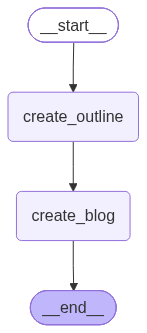

In [9]:
workflow

In [10]:
# define intial state.
intial_state = {
    'topic' : 'Explain about the Evolution of AI'
}

# execute the workflow.
final_state = workflow.invoke(intial_state)

# print final state
print(final_state)

{'topic': 'Explain about the Evolution of AI', 'outline': '**Outline: The Evolution of AI**\n\n**I. Introduction**  \n   A. Definition of Artificial Intelligence (AI)  \n   B. Importance of AI in modern society  \n   C. Overview of the evolution of AI  \n\n**II. Early Foundations of AI (1940s–1950s)**  \n   A. Conceptual beginnings: Alan Turing and the Turing Test  \n   B. Birth of AI as a field: Dartmouth Conference (1956)  \n   C. Early AI programs: Logic Theorist, General Problem Solver (GPS)  \n\n**III. The Era of Enthusiasm and Early Success (1960s–1970s)**  \n   A. Development of expert systems and rule-based AI  \n   B. Key milestones: ELIZA, SHRDLU, and early natural language processing  \n   C. Optimism and funding: Government and academic support  \n\n**IV. The AI Winter (1980s–1990s)**  \n   A. Limitations of early AI systems: Lack of scalability and adaptability  \n   B. Reduction in funding and interest  \n   C. Lessons learned: The need for more robust and flexible approa

In [11]:
final_state['outline']

'**Outline: The Evolution of AI**\n\n**I. Introduction**  \n   A. Definition of Artificial Intelligence (AI)  \n   B. Importance of AI in modern society  \n   C. Overview of the evolution of AI  \n\n**II. Early Foundations of AI (1940s–1950s)**  \n   A. Conceptual beginnings: Alan Turing and the Turing Test  \n   B. Birth of AI as a field: Dartmouth Conference (1956)  \n   C. Early AI programs: Logic Theorist, General Problem Solver (GPS)  \n\n**III. The Era of Enthusiasm and Early Success (1960s–1970s)**  \n   A. Development of expert systems and rule-based AI  \n   B. Key milestones: ELIZA, SHRDLU, and early natural language processing  \n   C. Optimism and funding: Government and academic support  \n\n**IV. The AI Winter (1980s–1990s)**  \n   A. Limitations of early AI systems: Lack of scalability and adaptability  \n   B. Reduction in funding and interest  \n   C. Lessons learned: The need for more robust and flexible approaches  \n\n**V. Revival and Breakthroughs (1990s–2000s)**  

In [12]:
final_state['topic']

'Explain about the Evolution of AI'

In [13]:
final_state['blog_content']

'# The Evolution of AI: A Journey from Concept to Ubiquity\n\n---\n\n## **I. Introduction**\n\n**A. Definition of Artificial Intelligence (AI)**  \nArtificial Intelligence (AI) refers to the simulation of human intelligence in machines programmed to think, learn, and make decisions. These systems are designed to perform tasks that typically require human cognition, such as problem-solving, understanding natural language, recognizing patterns, and adapting to new data.\n\n**B. Importance of AI in Modern Society**  \nAI has become a cornerstone of modern society, transforming industries, enhancing efficiency, and enabling innovations that were once the stuff of science fiction. From healthcare and finance to transportation and entertainment, AI’s impact is profound and far-reaching.\n\n**C. Overview of the Evolution of AI**  \nThe journey of AI from a theoretical concept to a transformative technology spans over seven decades. This blog explores the key milestones, challenges, and breakt